# FarmTech Solutions – Fase 5

## Machine Learning e Computação em Nuvem

### Análise e previsão de rendimento agrícola

Este notebook apresenta a análise exploratória dos dados agrícolas, a identificação de padrões por meio de aprendizado não supervisionado e o desenvolvimento e comparação de modelos de Machine Learning para previsão do rendimento das culturas.

### Integrantes

- **Gilenisson Lucas Bezerra dos Santos** – RM573716
- **Gabriela Brito Rocha Menezes** – RM574145

In [33]:
import pandas as pd

# Carregando o conjunto de dados
df = pd.read_csv("../data/crop_yield.csv")

# Visualizando as primeiras linhas
df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [34]:
# Dimensões do dataset
print("Linhas e colunas:", df.shape)

# Informações gerais
df.info()

Linhas e colunas: (156, 6)
<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 9.4 KB


In [35]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


In [36]:
# Verificando valores ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())

# Verificando linhas duplicadas
print("\nQuantidade de linhas duplicadas:")
print(df.duplicated().sum())

Valores ausentes por coluna:
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

Quantidade de linhas duplicadas:
0


In [37]:
# Verificando as culturas presentes no dataset
print("Culturas presentes no dataset:")
print(df["Crop"].unique())

print("\nQuantidade de registros por cultura:")
print(df["Crop"].value_counts())

Culturas presentes no dataset:
<ArrowStringArray>
['Cocoa, beans', 'Oil palm fruit', 'Rice, paddy', 'Rubber, natural']
Length: 4, dtype: str

Quantidade de registros por cultura:
Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


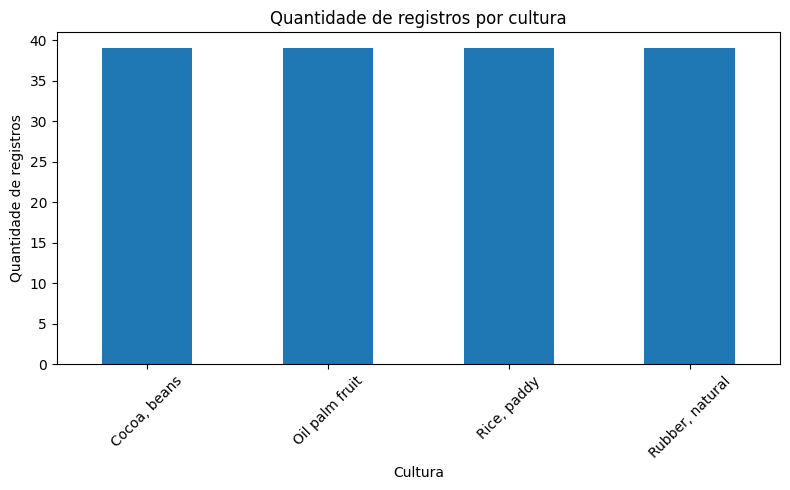

In [38]:
import matplotlib.pyplot as plt

# Quantidade de registros por cultura
contagem_culturas = df["Crop"].value_counts()

plt.figure(figsize=(8, 5))
contagem_culturas.plot(kind="bar")

plt.title("Quantidade de registros por cultura")
plt.xlabel("Cultura")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

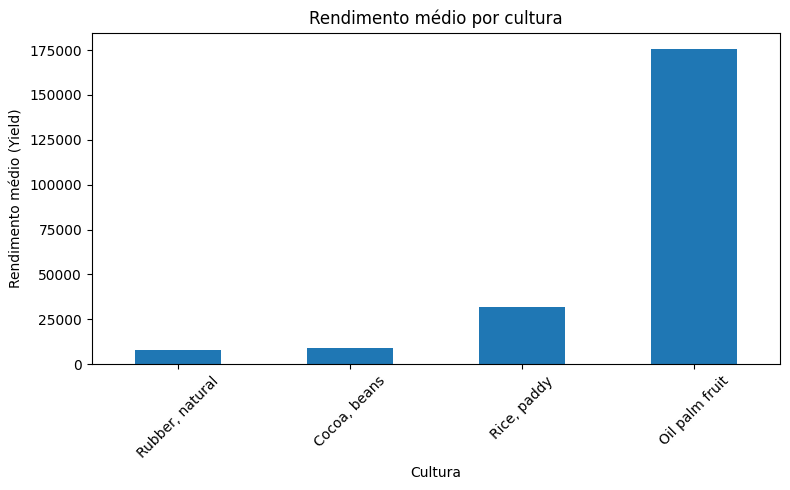

In [39]:
# Rendimento médio por cultura
rendimento_medio = df.groupby("Crop")["Yield"].mean().sort_values()

plt.figure(figsize=(8, 5))
rendimento_medio.plot(kind="bar")

plt.title("Rendimento médio por cultura")
plt.xlabel("Cultura")
plt.ylabel("Rendimento médio (Yield)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [40]:
# Rendimento médio de cada cultura
rendimento_medio = df.groupby("Crop")["Yield"].mean().sort_values(ascending=False)

print("Rendimento médio por cultura:")
print(rendimento_medio)

Rendimento médio por cultura:
Crop
Oil palm fruit     175804.692308
Rice, paddy         32099.666667
Cocoa, beans         8883.128205
Rubber, natural      7824.897436
Name: Yield, dtype: float64


In [41]:
# Correlação entre as variáveis numéricas
colunas_numericas = df.select_dtypes(include="number")

correlacao = colunas_numericas.corr()

print("Matriz de correlação:")
correlacao

Matriz de correlação:


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
Precipitation (mm day-1),1.000000,0.488483,0.749464,-0.083927,0.018830
Specific Humidity at 2 Meters (g/kg),0.488483,1.000000,0.436687,0.699230,0.012651
Relative Humidity at 2 Meters (%),0.749464,0.436687,1.000000,-0.337313,0.000008
Temperature at 2 Meters (C),-0.083927,0.699230,-0.337313,1.000000,0.013007
Yield,0.018830,0.012651,0.000008,0.013007,1.000000


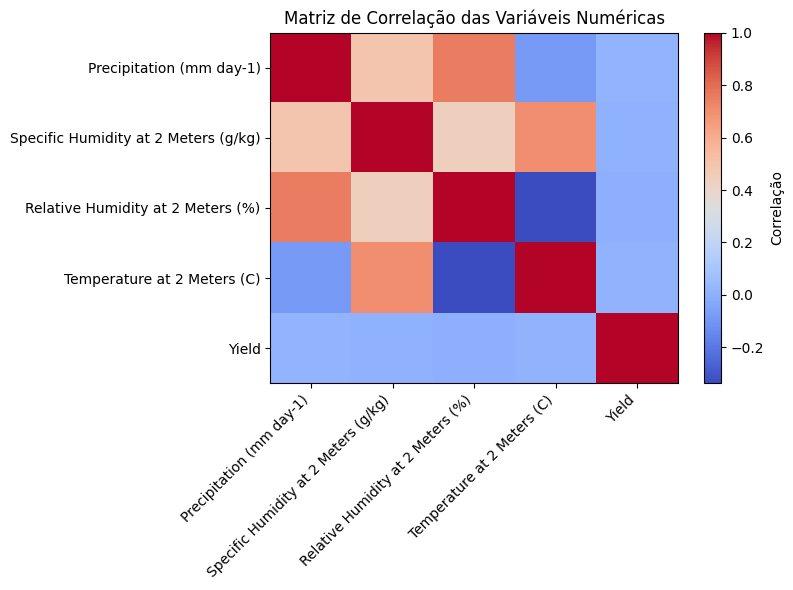

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(correlacao, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlação")

plt.xticks(
    range(len(correlacao.columns)),
    correlacao.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlacao.columns)),
    correlacao.columns
)

plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.tight_layout()

plt.show()

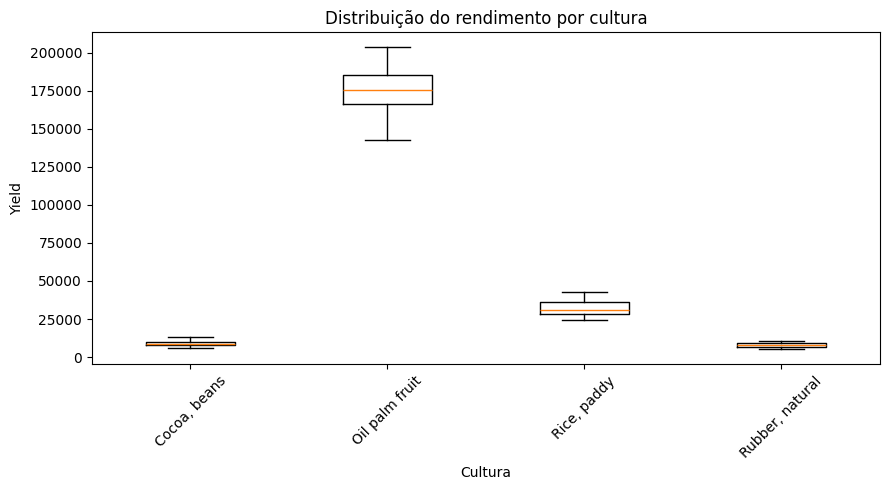

In [43]:
# Distribuição do rendimento por cultura

dados_boxplot = [
    df[df["Crop"] == cultura]["Yield"]
    for cultura in df["Crop"].unique()
]

plt.figure(figsize=(9, 5))

plt.boxplot(
    dados_boxplot,
    tick_labels=df["Crop"].unique()
)

plt.title("Distribuição do rendimento por cultura")
plt.xlabel("Cultura")
plt.ylabel("Yield")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [44]:
# Médias das variáveis por cultura
medias_por_cultura = df.groupby("Crop").mean(numeric_only=True)

print("Médias das variáveis por cultura:")
medias_por_cultura

Médias das variáveis por cultura:


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
Crop,,,,,
"Cocoa, beans",2486.498974,18.203077,84.737692,26.18359,8883.128205
Oil palm fruit,2486.498974,18.203077,84.737692,26.18359,175804.692308
"Rice, paddy",2486.498974,18.203077,84.737692,26.18359,32099.666667
"Rubber, natural",2486.498974,18.203077,84.737692,26.18359,7824.897436


In [45]:
# Separando variáveis de entrada (X) e variável alvo (y)

X = df.drop("Yield", axis=1)
y = df["Yield"]

print("Variáveis de entrada:")
print(X.columns)

print("\nVariável alvo:")
print(y.name)

Variáveis de entrada:
Index(['Crop', 'Precipitation (mm day-1)',
       'Specific Humidity at 2 Meters (g/kg)',
       'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)'],
      dtype='str')

Variável alvo:
Yield


## 2. Clusterização e identificação de tendências

Nesta etapa, serão utilizados métodos de aprendizado não supervisionado para identificar grupos com características semelhantes e investigar possíveis tendências relacionadas ao rendimento agrícola.

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [47]:
# Selecionando apenas as variáveis numéricas para a clusterização
variaveis_cluster = df[
    [
        "Precipitation (mm day-1)",
        "Specific Humidity at 2 Meters (g/kg)",
        "Relative Humidity at 2 Meters (%)",
        "Temperature at 2 Meters (C)",
        "Yield"
    ]
]

# Padronizando os dados
scaler = StandardScaler()
dados_padronizados = scaler.fit_transform(variaveis_cluster)

print("Formato dos dados padronizados:", dados_padronizados.shape)

Formato dos dados padronizados: (156, 5)


In [48]:
# Testando diferentes quantidades de clusters

resultados_silhouette = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    clusters = kmeans.fit_predict(dados_padronizados)
    score = silhouette_score(dados_padronizados, clusters)
    
    resultados_silhouette.append(score)
    print(f"k = {k} | Silhouette Score = {score:.4f}")

k = 2 | Silhouette Score = 0.3165
k = 3 | Silhouette Score = 0.3330
k = 4 | Silhouette Score = 0.3628
k = 5 | Silhouette Score = 0.3741
k = 6 | Silhouette Score = 0.3551


In [49]:
# Criando o modelo final de clusterização com k = 5

kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans_final.fit_predict(dados_padronizados)

print("Quantidade de registros por cluster:")
print(df["Cluster"].value_counts().sort_index())

Quantidade de registros por cluster:
Cluster
0    57
1    13
2    37
3    24
4    25
Name: count, dtype: int64


In [50]:
# Analisando as características médias de cada cluster

perfil_clusters = df.groupby("Cluster")[
    [
        "Precipitation (mm day-1)",
        "Specific Humidity at 2 Meters (g/kg)",
        "Relative Humidity at 2 Meters (%)",
        "Temperature at 2 Meters (C)",
        "Yield"
    ]
].mean()

perfil_clusters

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
Cluster,,,,,
0,2707.441579,18.340000,85.562105,26.139474,16715.333333
1,2397.468462,17.652308,84.560000,25.707692,65178.000000
2,2152.201892,17.927838,83.764595,26.132973,43737.135135
3,2371.156250,18.472083,83.854583,26.614167,36259.541667
4,2634.534400,18.326400,85.238400,26.193200,178851.680000


In [51]:
# Verificando a distribuição das culturas em cada cluster

distribuicao_culturas = pd.crosstab(
    df["Cluster"],
    df["Crop"]
)

print("Distribuição das culturas por cluster:")
distribuicao_culturas

Distribuição das culturas por cluster:


Crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
Cluster,,,,
0,19,0,19,19
1,3,4,3,3
2,10,7,10,10
3,7,3,7,7
4,0,25,0,0


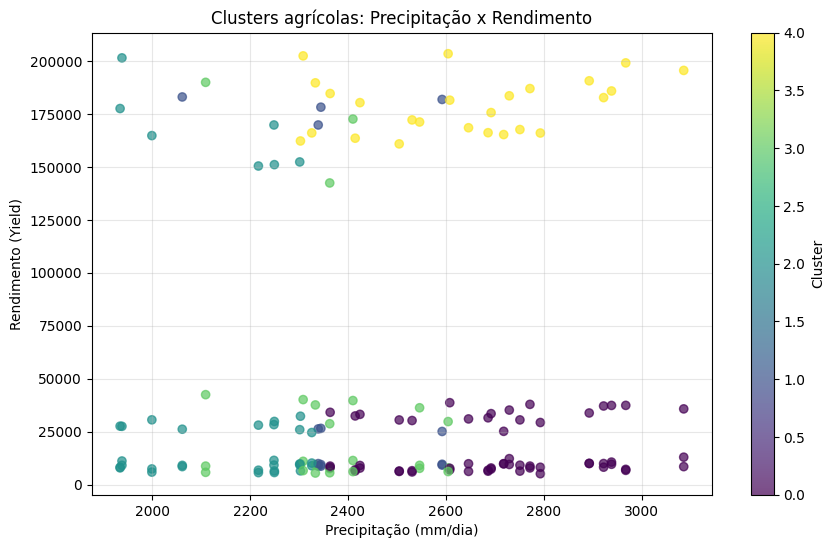

In [52]:
import matplotlib.pyplot as plt

# Visualização dos clusters: precipitação x rendimento

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["Precipitation (mm day-1)"],
    df["Yield"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Precipitação (mm/dia)")
plt.ylabel("Rendimento (Yield)")
plt.title("Clusters agrícolas: Precipitação x Rendimento")

plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)

plt.show()

### Interpretação dos resultados do K-Means

A análise de agrupamento com K-Means identificou cinco clusters com diferentes características agrícolas.

O Cluster 4 apresentou o maior rendimento médio e foi composto exclusivamente por registros da cultura *Oil palm fruit*, indicando uma forte diferenciação dessa cultura em relação às demais.

O gráfico de precipitação versus rendimento evidencia essa separação, com registros de maior rendimento concentrados na região superior do gráfico.

Os resultados demonstram que o algoritmo conseguiu identificar padrões relevantes nos dados mesmo sem utilizar previamente os rótulos das culturas para definir os grupos.

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Variáveis de entrada
X = df[
    [
        "Crop",
        "Precipitation (mm day-1)",
        "Specific Humidity at 2 Meters (g/kg)",
        "Relative Humidity at 2 Meters (%)",
        "Temperature at 2 Meters (C)"
    ]
]

# Variável que queremos prever
y = df["Yield"]

# Separando dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Dados de treino:", X_train.shape)
print("Dados de teste:", X_test.shape)

Dados de treino: (124, 5)
Dados de teste: (32, 5)


In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Pré-processamento da variável categórica "Crop"
preprocessor = ColumnTransformer(
    transformers=[
        ("crop", OneHotEncoder(handle_unknown="ignore"), ["Crop"])
    ],
    remainder="passthrough"
)

# Pipeline com pré-processamento + Regressão Linear
modelo_linear = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("modelo", LinearRegression())
    ]
)

# Treinando o modelo
modelo_linear.fit(X_train, y_train)

# Fazendo previsões
y_pred_linear = modelo_linear.predict(X_test)

# Avaliação
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Regressão Linear")
print(f"MAE: {mae_linear:.2f}")
print(f"MSE: {mse_linear:.2f}")
print(f"R²: {r2_linear:.4f}")

Regressão Linear
MAE: 3132.80
MSE: 19308693.24
R²: 0.9950


In [55]:
from sklearn.ensemble import RandomForestRegressor

# Criando o modelo Random Forest
modelo_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("modelo", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

# Treinando o modelo
modelo_rf.fit(X_train, y_train)

# Fazendo previsões
y_pred_rf = modelo_rf.predict(X_test)

# Avaliando o modelo
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print(f"MAE: {mae_rf:.2f}")
print(f"MSE: {mse_rf:.2f}")
print(f"R²: {r2_rf:.4f}")

Random Forest
MAE: 2705.92
MSE: 21793824.05
R²: 0.9944


In [56]:
# Comparação dos modelos

resultados_modelos = pd.DataFrame({
    "Modelo": ["Regressão Linear", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "MSE": [mse_linear, mse_rf],
    "R²": [r2_linear, r2_rf]
})

resultados_modelos

,Modelo,MAE,MSE,R²
0,Regressão Linear,3132.796384,1.930869e+07,0.995022
1,Random Forest,2705.921563,2.179382e+07,0.994382


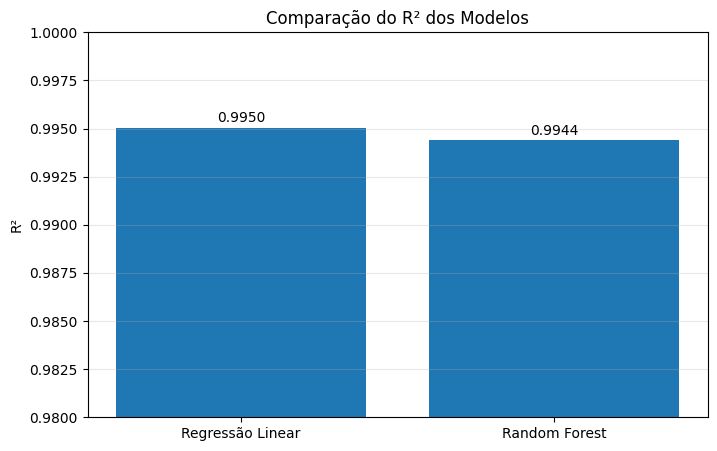

In [57]:
# Comparação visual do R² dos modelos

plt.figure(figsize=(8, 5))

plt.bar(
    resultados_modelos["Modelo"],
    resultados_modelos["R²"]
)

plt.title("Comparação do R² dos Modelos")
plt.ylabel("R²")
plt.ylim(0.98, 1.0)

# Exibindo o valor sobre cada barra
for i, valor in enumerate(resultados_modelos["R²"]):
    plt.text(i, valor + 0.0003, f"{valor:.4f}", ha="center")

plt.grid(axis="y", alpha=0.3)
plt.show()

### Comparação dos modelos supervisionados

Foram avaliados dois algoritmos de regressão para previsão do rendimento agrícola: **Regressão Linear** e **Random Forest Regressor**.

Os dois modelos apresentaram excelente desempenho, com valores de R² superiores a 0,99.

A **Regressão Linear** apresentou R² de aproximadamente **0,9950**, ligeiramente superior ao Random Forest, que apresentou aproximadamente **0,9944**. Além disso, a Regressão Linear apresentou menor MSE.

Por outro lado, o **Random Forest apresentou menor MAE**, indicando menor erro absoluto médio nas previsões.

Portanto, ambos os modelos apresentaram resultados satisfatórios. Considerando o R² e o MSE, a Regressão Linear apresentou uma pequena vantagem neste conjunto de dados, enquanto o Random Forest apresentou vantagem em relação ao MAE.

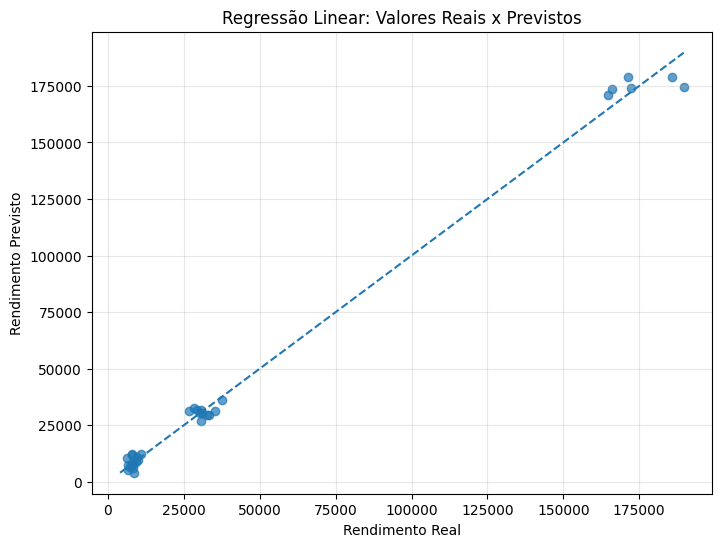

In [58]:
# Comparação entre valores reais e previstos pela Regressão Linear

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.7
)

# Linha de referência: previsão perfeita
valor_min = min(y_test.min(), y_pred_linear.min())
valor_max = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [valor_min, valor_max],
    [valor_min, valor_max],
    linestyle="--"
)

plt.xlabel("Rendimento Real")
plt.ylabel("Rendimento Previsto")
plt.title("Regressão Linear: Valores Reais x Previstos")

plt.grid(alpha=0.3)
plt.show()

### Análise dos valores reais e previstos

O gráfico apresenta a comparação entre os valores reais de rendimento agrícola e os valores previstos pelo modelo de Regressão Linear.

Observa-se que a maioria dos pontos está próxima da linha diagonal de referência, indicando que as previsões apresentam valores muito próximos dos dados reais.

Esse comportamento é consistente com o elevado coeficiente de determinação obtido pelo modelo (R² = 0,9950), demonstrando um excelente desempenho preditivo no conjunto de teste.

Apesar de pequenos desvios em algumas observações, principalmente entre os maiores valores de rendimento, o modelo apresentou boa capacidade de generalização para os dados analisados.

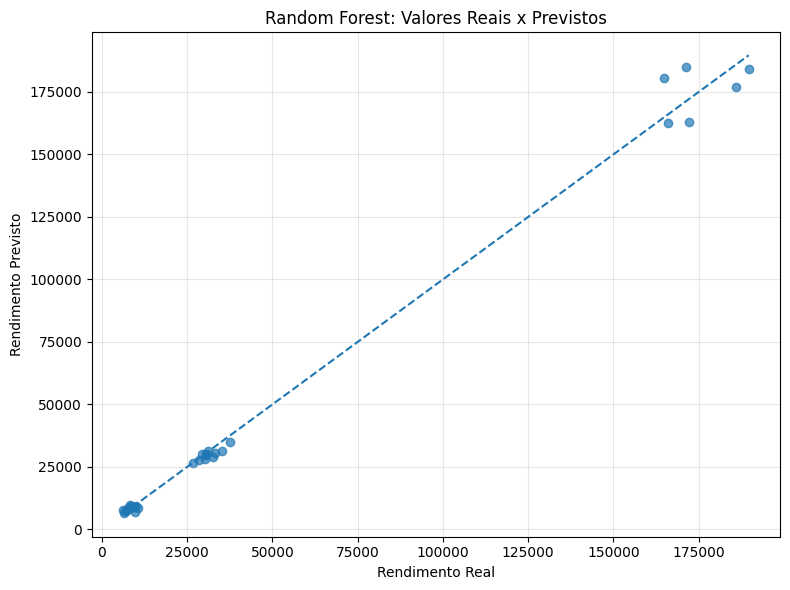

In [59]:
# Comparação entre valores reais e previstos - Random Forest

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Rendimento Real")
plt.ylabel("Rendimento Previsto")
plt.title("Random Forest: Valores Reais x Previstos")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Análise dos modelos de regressão

Os dois modelos apresentaram excelente desempenho na previsão do rendimento agrícola.

A Regressão Linear apresentou R² de aproximadamente 0,9950, enquanto o Random Forest apresentou R² de aproximadamente 0,9944. Esses valores indicam que ambos os modelos conseguem explicar grande parte da variação observada no rendimento das culturas.

Nos gráficos de valores reais versus valores previstos, observa-se que os pontos permanecem próximos da linha de referência, indicando boa capacidade preditiva.

Embora o Random Forest tenha apresentado menor MAE, a Regressão Linear obteve menor MSE e um R² ligeiramente superior. Dessa forma, considerando o conjunto das métricas avaliadas, a Regressão Linear apresentou o melhor desempenho geral neste conjunto de dados.

## Conclusão da análise de Machine Learning

A análise realizada permitiu explorar diferentes abordagens de Machine Learning aplicadas aos dados agrícolas.

Na etapa de aprendizado não supervisionado, o algoritmo K-Means foi utilizado para identificar padrões e formar grupos com características semelhantes. A avaliação pelo Silhouette Score indicou melhor resultado para 5 clusters, permitindo observar diferentes perfis relacionados às condições ambientais e ao rendimento das culturas.

Na etapa de aprendizado supervisionado, foram utilizados os modelos de Regressão Linear e Random Forest para prever o rendimento agrícola (Yield).

Os dois modelos apresentaram desempenho elevado, com valores de R² superiores a 0,99. A Regressão Linear apresentou R² ligeiramente superior, enquanto o Random Forest apresentou menor erro absoluto médio (MAE).

Os resultados demonstram que técnicas de Machine Learning podem ser utilizadas para identificar padrões nos dados agrícolas e apoiar a previsão do rendimento das culturas a partir das condições ambientais disponíveis no conjunto de dados.

## Conclusão da análise de Machine Learning

A análise realizada permitiu aplicar técnicas de aprendizado não supervisionado e supervisionado aos dados agrícolas, buscando identificar padrões e prever o rendimento das culturas.

Na etapa de aprendizado não supervisionado, o algoritmo K-Means foi utilizado para identificar grupos com características semelhantes. A avaliação por meio do Silhouette Score indicou melhor resultado com cinco clusters, permitindo observar diferentes perfis relacionados às condições ambientais e ao rendimento agrícola.

A análise de outliers foi realizada pelo método do Intervalo Interquartil (IQR), considerando cada cultura separadamente. Pelo critério adotado, não foram identificados valores discrepantes de rendimento dentro das culturas analisadas.

Na etapa de aprendizado supervisionado, foram avaliados cinco algoritmos de regressão: Regressão Linear, Random Forest, Decision Tree, Gradient Boosting e K-Nearest Neighbors (KNN).

Entre os modelos avaliados, a Regressão Linear apresentou o melhor desempenho geral no conjunto de teste, com R² de aproximadamente 0,9950 e o menor MSE. O Random Forest também apresentou excelente desempenho e obteve o menor MAE. Decision Tree e Gradient Boosting alcançaram valores de R² superiores a 0,99, enquanto o KNN apresentou desempenho significativamente inferior, com R² negativo.

Os resultados demonstram que a escolha do algoritmo e o tratamento adequado das características dos dados influenciam diretamente o desempenho dos modelos. Apesar dos resultados elevados obtidos por alguns algoritmos, o tamanho reduzido do conjunto de dados e as diferenças de rendimento entre as culturas devem ser considerados ao interpretar os resultados.

In [60]:
# Importando o modelo de Árvore de Decisão
from sklearn.tree import DecisionTreeRegressor

# Criando o pipeline com o pré-processamento e o modelo
modelo_dt = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42))
])

# Treinando o modelo
modelo_dt.fit(X_train, y_train)

# Realizando as previsões
y_pred_dt = modelo_dt.predict(X_test)

# Calculando as métricas
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree")
print(f"MAE: {mae_dt:.2f}")
print(f"MSE: {mse_dt:.2f}")
print(f"R²: {r2_dt:.4f}")

Decision Tree
MAE: 3404.44
MSE: 31495583.69
R²: 0.9919


In [61]:
# Importando o modelo Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

# Criando o pipeline com pré-processamento e modelo
modelo_gb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(random_state=42))
])

# Treinando o modelo
modelo_gb.fit(X_train, y_train)

# Realizando previsões
y_pred_gb = modelo_gb.predict(X_test)

# Calculando as métricas
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print(f"MAE: {mae_gb:.2f}")
print(f"MSE: {mse_gb:.2f}")
print(f"R²: {r2_gb:.4f}")

Gradient Boosting
MAE: 3080.05
MSE: 36887957.64
R²: 0.9905


In [62]:
# Importando o modelo KNN para regressão
from sklearn.neighbors import KNeighborsRegressor

# Criando o pipeline com pré-processamento e modelo
modelo_knn = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", KNeighborsRegressor(n_neighbors=5))
])

# Treinando o modelo
modelo_knn.fit(X_train, y_train)

# Realizando previsões
y_pred_knn = modelo_knn.predict(X_test)

# Calculando as métricas
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regressor")
print(f"MAE: {mae_knn:.2f}")
print(f"MSE: {mse_knn:.2f}")
print(f"R²: {r2_knn:.4f}")

KNN Regressor
MAE: 61324.36
MSE: 5316164952.44
R²: -0.3705


In [63]:
# Recuperando as métricas dos modelos anteriores
mae_lr = 3132.796384
mse_lr = 19308693.24
r2_lr = 0.995022

mae_rf = 2705.921563
mse_rf = 21793824.05
r2_rf = 0.994382

# Criando a tabela de comparação dos cinco modelos
comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "Regressão Linear",
        "Random Forest",
        "Decision Tree",
        "Gradient Boosting",
        "KNN"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_dt,
        mae_gb,
        mae_knn
    ],
    "MSE": [
        mse_lr,
        mse_rf,
        mse_dt,
        mse_gb,
        mse_knn
    ],
    "R²": [
        r2_lr,
        r2_rf,
        r2_dt,
        r2_gb,
        r2_knn
    ]
})

# Ordenando os modelos pelo R²
comparacao_modelos = comparacao_modelos.sort_values(
    by="R²",
    ascending=False
)

comparacao_modelos

,Modelo,MAE,MSE,R²
0,Regressão Linear,3132.796384,1.930869e+07,0.995022
1,Random Forest,2705.921563,2.179382e+07,0.994382
2,Decision Tree,3404.437500,3.149558e+07,0.991880
3,Gradient Boosting,3080.047594,3.688796e+07,0.990490
4,KNN,61324.356250,5.316165e+09,-0.370509


### Comparação dos cinco modelos de regressão

Foram avaliados cinco algoritmos de regressão para prever o rendimento agrícola: Regressão Linear, Random Forest, Decision Tree, Gradient Boosting e K-Nearest Neighbors (KNN).

A **Regressão Linear** apresentou o maior coeficiente de determinação (R² = 0,9950) e o menor MSE entre os modelos avaliados, indicando excelente capacidade de explicar a variação do rendimento no conjunto de teste.

O **Random Forest** também apresentou ótimo desempenho, com R² = 0,9944, além de obter o menor MAE entre os cinco modelos, indicando menor erro absoluto médio nas previsões.

Os modelos **Decision Tree** e **Gradient Boosting** também apresentaram resultados elevados, com valores de R² superiores a 0,99, embora tenham ficado ligeiramente abaixo dos dois primeiros modelos.

Por outro lado, o **KNN apresentou desempenho significativamente inferior**, com R² negativo (-0,3705) e erros muito superiores aos demais modelos. Esse resultado indica que, na configuração utilizada, o KNN não conseguiu representar adequadamente a relação entre as variáveis de entrada e o rendimento agrícola.

Considerando conjuntamente as métricas MAE, MSE e R², a **Regressão Linear apresentou o melhor desempenho geral neste conjunto de teste**, enquanto o Random Forest também demonstrou resultados bastante competitivos.

In [64]:
# Identificação de possíveis outliers de rendimento por cultura
# utilizando o método do Intervalo Interquartil (IQR)

outliers = []

for cultura, grupo in df.groupby("Crop"):
    # Calculando os quartis
    q1 = grupo["Yield"].quantile(0.25)
    q3 = grupo["Yield"].quantile(0.75)

    # Calculando o intervalo interquartil
    iqr = q3 - q1

    # Definindo os limites para identificação de outliers
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Identificando valores fora dos limites
    valores_outliers = grupo[
        (grupo["Yield"] < limite_inferior) |
        (grupo["Yield"] > limite_superior)
    ].copy()

    valores_outliers["Limite Inferior"] = limite_inferior
    valores_outliers["Limite Superior"] = limite_superior

    outliers.append(valores_outliers)

# Reunindo os resultados
outliers_yield = pd.concat(outliers)

print("Quantidade de possíveis outliers:", len(outliers_yield))

outliers_yield[
    ["Crop", "Yield", "Limite Inferior", "Limite Superior"]
]

Quantidade de possíveis outliers: 0


,Crop,Yield,Limite Inferior,Limite Superior


### Análise de Outliers

Para identificar possíveis cenários discrepantes no rendimento agrícola, foi utilizado o método do Intervalo Interquartil (IQR).

A análise foi realizada separadamente para cada cultura, pois os níveis de rendimento apresentam diferenças significativas entre os tipos de plantação. Dessa forma, evita-se classificar como anomalia um rendimento elevado que seja característico de determinada cultura.

Utilizando os limites de 1,5 vezes o intervalo interquartil abaixo do primeiro quartil (Q1) e acima do terceiro quartil (Q3), não foram identificados outliers na variável `Yield` dentro de nenhuma das culturas analisadas.

Portanto, os valores elevados observados em determinadas culturas representam diferenças próprias dos dados de rendimento de cada cultura e não foram considerados cenários discrepantes pelo critério adotado.

### Pontos fortes e limitações

#### Pontos fortes

O trabalho combinou técnicas de aprendizado não supervisionado e supervisionado, permitindo analisar os dados agrícolas sob diferentes perspectivas.

A utilização do K-Means possibilitou identificar grupos com características semelhantes, enquanto a comparação entre cinco algoritmos de regressão permitiu avaliar diferentes abordagens para a previsão do rendimento agrícola.

Além disso, foram utilizadas métricas como MAE, MSE e R² para comparar objetivamente o desempenho dos modelos.

#### Limitações

O conjunto de dados utilizado possui apenas 156 registros, o que representa uma quantidade relativamente pequena de observações para o treinamento e avaliação de modelos de Machine Learning.

Também foram observadas diferenças expressivas de rendimento entre as culturas, fazendo com que a variável `Crop` tenha grande importância para a previsão de `Yield`.

Os resultados apresentados correspondem ao conjunto de treino e teste utilizado neste estudo. Portanto, o desempenho obtido não garante que os modelos apresentem os mesmos resultados quando aplicados a novos dados agrícolas coletados em outras condições.

Por fim, alguns algoritmos podem exigir ajustes adicionais de hiperparâmetros e de pré-processamento. O baixo desempenho observado no KNN, por exemplo, demonstra que diferentes algoritmos podem responder de maneira distinta às características e escalas presentes no conjunto de dados.